# Syntetic magnetic compton profiles

In [1]:

import numpy as np
import torch
from Richardson_lucy_functions import convo1d, gaussian_kernel_1D, poisson_noise
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.integrate as integrate
from scipy.optimize import curve_fit
from symfit import parameters, variables, sin, cos, Fit
import pandas as pd



Defining all variables used:

In [ ]:
#grid parameters
Npts = 2401
pz_min = -12.5
pz_max = 12.5

# physical parameters
n_gauss = 5
fourier_order = 5
spin_asymm = 0.8

# experimental parameters
t_count = 5e5
res_fwhm = 0.12
err_scaling = 1

# random parameters
gauss_width_range = (0.3, 1.0)
gauss_amp_range = (0.05, 1.0)
parab_curv_range = (0.5, 1.5)
parab_offset_range = (1.5, 2.5)

fermi_window_width = 2
fermi_window_amp = 0.5
fermi_scale_range = (-2, -1.5)
fermi_coeff_range = 0.2

n_train = 200000
n_test = 50000

pz = np.linspace(pz_min, pz_max, Npts)
grid_spacing = np.abs(pz[1] - pz[0])
res_sigma = res_fwhm / (2 * np.sqrt(2 * np.log(2))) / grid_spacing

rng = np.random.default_rng()


Defining core functions:

In [3]:
def gaussian(x, width, amp):
    return (np.abs(amp) * np.exp(-0.5 * (x /(np.abs(width))) ** 2))


def parabola(x, vertex, curve, offset):
    return offset - curve * (x - vertex) ** 2


def fourier_series(x, a_coeffs, b_coeffs, frequency, n=0):

    result = a_coeffs[0] * np.ones_like(x)

    for i in range(1, n + 1):
            result += a_coeffs[i] * np.cos(i * frequency * x)
            if i <= len(b_coeffs):
                result += b_coeffs[i-1] * np.sin(i * frequency * x)

    return result


fermi_window = gaussian(pz, fermi_window_width, fermi_window_amp)

#test 
print(fermi_window.max())

0.5


In [ ]:
from Richardson_lucy_functions import convo1d, gaussian_kernel_1D, poisson_noise

def blur(y, sigma):
    kernel = gaussian_kernel_1D(size=201, sigma=sigma)
    y = signal.convolve(y, kernel, mode='same')
    return y

def noise(y):
    y_noisy = y + np.sqrt(np.abs(y)) * np.random.normal(0,0.1,size=y.shape)
    return y_noisy

def poisson_noise(y, scale_factor):
    y = np.random.poisson(y * scale_factor) / scale_factor
    return y

def old_noise(cp, pz, total_counts):
    # Scale profile to total counts
    cp_scaled = cp * total_counts
    # Apply Stephen's guessed error distribution
    # The (1 + 0.31 * abs(pz)) factor damps noise at high momentum
    error = np.sqrt(cp_scaled) / (1 + 0.31 * np.abs(pz))
    # Add noise to the profile
    noise = np.random.normal(0, error)
    y = cp_scaled + noise
    return y

def normalise(y, x):
    area = integrate.simpson(y, x)
    y = (10 * y) / (area / 1)
    return y 


def height_normalise(y, x):
    max_val = np.max(y)
    return y / max_val if max_val > 0 else y


def sign_consitency(y):
    if y[0] > 0:
        return np.all(y > 0)
    else:
        return np.all(y < 0)
    


# def normalise(y, x):
#     area = integrate.simpson(y, x)
#     y = (1 * y) / (area / 1)
#     return y / area if area > 0 else y
    


Generating random parameters:

In [5]:
def gen_gauss_params(n_gauss, gauss_width_range, gauss_amp_range, rng, amp=1.0):
   
    params = []

    for _ in range(n_gauss):
        width = rng.uniform(*gauss_width_range)
        amp = rng.uniform(*gauss_amp_range)
        params.extend([width, amp])
    return params


def gen_parab_params(parab_curv_range, parab_offset_range, rng):
    vertex = 0.0
    curve = rng.uniform(*parab_curv_range)
    offset = rng.uniform(*parab_offset_range)
    
    return vertex, curve, offset

def gen_fourier_coeffs(fourier_order, fermi_coeff_range, rng):
    a_coeffs = np.zeros(fourier_order + 1)
    a_coeffs[0] = 0.0
    a_coeffs[1:] = rng.uniform(-fermi_coeff_range, fermi_coeff_range, size=fourier_order)
    
    b_coeffs = np.zeros(fourier_order)

    return a_coeffs, b_coeffs



In [6]:
def evaluate_base_model(x, n_gauss, gauss_width_range, gauss_amp_range, parab_curv_range, parab_offset_range,rng):
    y = np.zeros_like(x)

    # Add Gaussian peaks
    gauss_params = gen_gauss_params(n_gauss, gauss_width_range, gauss_amp_range, rng)
    for i in range(n_gauss):
        width = gauss_params[i*2]
        amp = gauss_params[i*2 + 1]
        y += gaussian(x, width, amp)

    # Add parabolic background
    vertex, curve, offset = gen_parab_params(parab_curv_range, parab_offset_range, rng)
    parab = parabola(x, vertex, curve, offset)

    for i in range(len(y)):
        if y[i] < parab[i]:
            y[i] = parab[i]
        else:
            y[i] = y[i]

    y *= gaussian(x, 2.5, 1.5)

    #y = y[:(Npts-1)//2]


    all_params = gauss_params + [vertex, curve, offset]

    return y, all_params

def add_fermi_features(y, x, fermi_window, fermi_scale_range, fermi_coeff_range, rng):

    fermi_scale = rng.uniform(*fermi_scale_range)
    a_coeffs, b_coeffs = gen_fourier_coeffs(fourier_order, fermi_coeff_range, rng)
    fourier_component = fourier_series(x, a_coeffs, b_coeffs, frequency=1.0, n=fourier_order)
    y += fermi_window * (fermi_scale * fourier_component)

    return y



Test a single spin up profile:

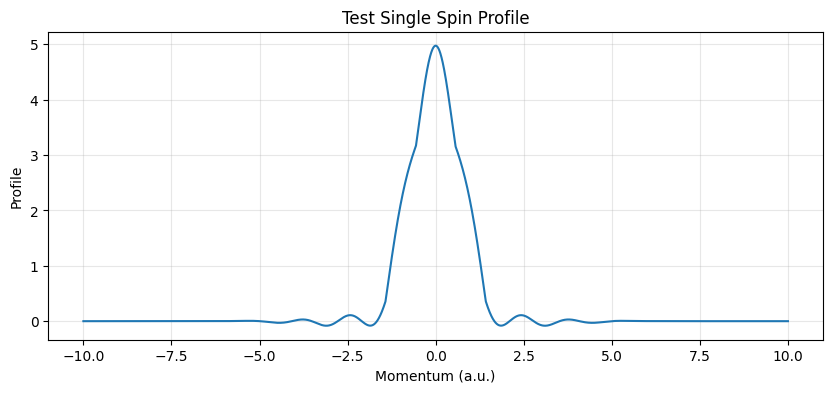

In [11]:
#Test...
def generate_single_spin_profile(x, n_gauss, gauss_width_range, gauss_amp_range, parab_curv_range, parab_offset_range,fermi_scale_range, fermi_coeff_range, rng):
    base_y, params = evaluate_base_model(x, n_gauss, gauss_width_range, gauss_amp_range,parab_curv_range, parab_offset_range, rng)
    y_up = add_fermi_features(base_y, x, fermi_window, fermi_scale_range, fermi_coeff_range, rng)
    return y_up


test_profile = generate_single_spin_profile(pz, n_gauss, gauss_width_range, gauss_amp_range, parab_curv_range, parab_offset_range, fermi_scale_range, fermi_coeff_range, rng)

plt.figure(figsize=(10, 4))
plt.plot(pz, test_profile)
plt.xlabel('Momentum (a.u.)')
plt.ylabel('Profile')
plt.title('Test Single Spin Profile')
plt.grid(True, alpha=0.3)
plt.show()


Successful (hopefully...)

Now build a full MCP:

In [12]:
def generate_mcp(x, n_gauss, gauss_width_range, gauss_amp_range, parab_curv_range, parab_offset_range, fermi_scale_range, fermi_coeff_range, rng, spin_asymm = 0.8):
    y_up = generate_single_spin_profile(x, n_gauss, gauss_width_range, gauss_amp_range, parab_curv_range, parab_offset_range, fermi_scale_range, fermi_coeff_range, rng)
    y_down = generate_single_spin_profile(x, n_gauss, gauss_width_range, gauss_amp_range, parab_curv_range, parab_offset_range, fermi_scale_range, fermi_coeff_range, rng)

    y_up = normalise(y_up, x)
    y_down = normalise(y_down, x)

    mcp = y_down - spin_asymm * y_up

    # additional gaussian to avoid negative values and maintain physicallity
    amp = 3
    width = 3

    mcp = mcp + np.abs(amp) * np.exp(-0.5 * (x /(np.abs(width))) ** 2)
    mcp_clean = normalise(mcp, x)

    y_up_blur   = blur(y_up, res_sigma)
    y_down_blur = blur(y_down, res_sigma)
    mcp_blur = (y_down_blur - spin_asymm * y_up_blur) + np.abs(amp) * np.exp(-0.5 * (x /(np.abs(width))) ** 2)
    mcp_blur = normalise(mcp_blur, x)

    y_up_noisy   = noise(y_up)
    y_down_noisy = noise(y_down)
    mcp_noisy = (y_down_noisy - spin_asymm * y_up_noisy) + np.abs(amp) * np.exp(-0.5 * (x /(np.abs(width))) ** 2)
    mcp_noisy    = normalise(mcp_noisy, x)

    y_up_bn   = noise(y_up_blur)
    y_down_bn = noise(y_down_blur)
    mcp_bn = (y_down_bn - spin_asymm * y_up_bn) + np.abs(amp) * np.exp(-0.5 * (x /(np.abs(width))) ** 2)
    mcp_bn    = normalise(mcp_bn, x)

    return mcp_clean, mcp_blur, mcp_noisy, mcp_bn

Since creation, messing around with features of the code in the aim of optimising other features has meant that i have broken this function. it worked initially

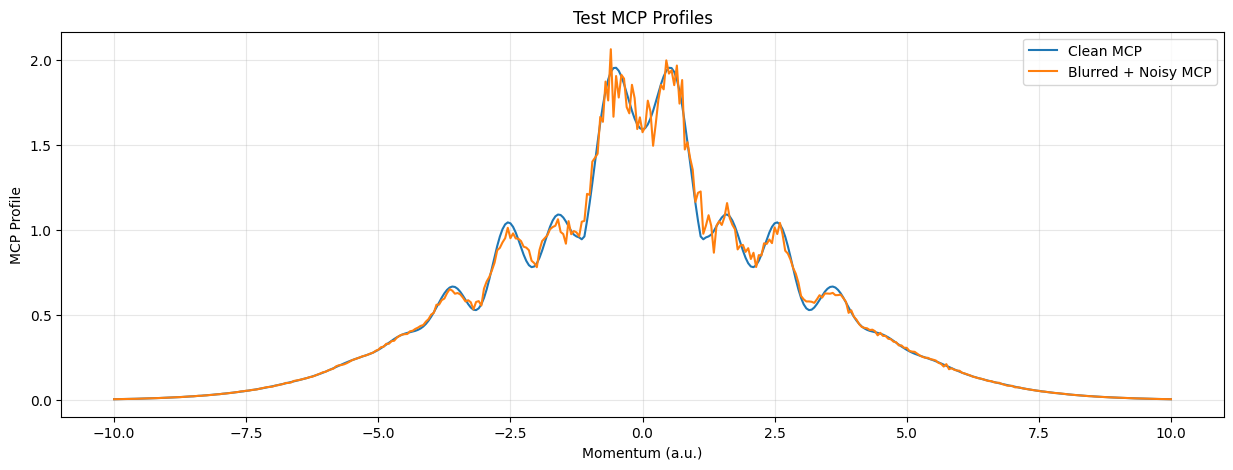

In [402]:
#grid parameters
Npts = 401
pz_min = -10
pz_max = 10

# physical parameters
n_gauss = 5
fourier_order = 7
spin_asymm = 0.8

# experimental parameters
t_count = 5e5
res_fwhm = 0.35
err_scaling = 1

# random parameters
gauss_width_range = (0.3, 2.0)
gauss_amp_range = (0.05, 0.5)
parab_curv_range = (0.5, 1.5)
parab_offset_range = (1.5, 2.5)

fermi_window_width = 2
fermi_window_amp = 0.2
fermi_scale_range = (-4, -3)
fermi_coeff_range = 0.5

n_train = 200000
n_test = 50000

pz = np.linspace(pz_min, pz_max, Npts)
grid_spacing = np.abs(pz[1] - pz[0])
res_sigma = res_fwhm / (2 * np.sqrt(2 * np.log(2))) / grid_spacing
fermi_window = gaussian(pz, fermi_window_width, fermi_window_amp)

rng = np.random.default_rng()

from matplotlib.pyplot import figure, plot

mcp_clean, mcp_blur, mcp_noisy, mcp_blur_noisy = generate_mcp(pz, n_gauss, gauss_width_range, gauss_amp_range, parab_curv_range, parab_offset_range, fermi_scale_range, fermi_coeff_range, rng, spin_asymm = 0.8)

figure(figsize=(15, 5))
plot(pz, mcp_clean, label='Clean MCP')
#plot(pz, mcp_blur, label='Blurred MCP')
#plot(pz, mcp_noisy, label='Noisy MCP')
plot(pz, mcp_blur_noisy, label='Blurred + Noisy MCP')
plt.xlabel('Momentum (a.u.)')
plt.ylabel('MCP Profile')
#plt.ylim(0,0.2)
plt.title('Test MCP Profiles')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [210]:
from scipy.optimize import curve_fit

def fermi_model(x, fermi_window, *params):
    """Windowed Fourier series to capture Fermi edge oscillations."""
    n = (len(params)) // 2
    a_coeffs = params[:n]
    b_coeffs = params[n:]
    result = np.zeros_like(x, dtype=float)
    for i in range(1, n + 1):
        result += a_coeffs[i-1] * np.cos(i * x)
        if i <= len(b_coeffs):
            result += b_coeffs[i-1] * np.sin(i * x)
    return fermi_window * result

def compton_model(x, *params):
    """
    Gaussians with free centres — captures off-centre d-band peaks.
    params layout: [amp_0, width_0, centre_0, amp_1, width_1, centre_1, ..., curve, offset]
    """
    n = (len(params) - 2) // 3
    y = np.zeros_like(x, dtype=float)
    for i in range(n):
        amp    = abs(params[i*3])
        width  = abs(params[i*3 + 1])
        centre = params[i*3 + 2]        # free centre — key change
        y += gaussian(x - centre, width, amp)
    curve  = abs(params[-2])
    offset = abs(params[-1])
    y += np.maximum(0, offset - curve * x**2)
    return y


def fit_profile(x, y, fermi_window, n_gauss=5, n_fourier=7, label=''):
    n_params = n_gauss * 3 + 2

    # Seed one Gaussian at 0 and pairs at ±0.5, ±1.5 to hint at double peak
    p0 = []
    centres_guess = [0.0, 0.5, -0.5, 1.5, -1.5][:n_gauss]
    for c in centres_guess:
        p0 += [np.max(y) * 0.3, 0.8, c]
    p0 += [0.3, np.min(y)]

    # Bounds: amp/width positive, centres free between -5 and 5
    lower = []
    upper = []
    for _ in range(n_gauss):
        lower += [0,   0,   -5.0]
        upper += [np.inf, np.inf,  5.0]
    lower += [0, 0]
    upper += [np.inf, np.inf]

    try:
        popt, pcov = curve_fit(compton_model, x, y, p0=p0,
                               bounds=(lower, upper), maxfev=30000)
    except RuntimeError as e:
        print(f"{label}: smooth fit failed — {e}")
        return None, None, None, None, None

    y_smooth  = compton_model(x, *popt)
    residual  = y - y_smooth

    # Stage 2: Fermi features on residual — more terms for sharper features
    p0_fermi = np.zeros(n_fourier * 2)
    try:
        popt_fermi, pcov_fermi = curve_fit(
            lambda x, *p: fermi_model(x, fermi_window, *p),
            x, residual, p0=p0_fermi, maxfev=20000)
    except RuntimeError as e:
        print(f"{label}: Fermi fit failed — {e}")
        return None, None, None, None, None

    y_full = y_smooth + fermi_model(x, fermi_window, *popt_fermi)

    r2 = 1 - np.sum((y - y_full)**2) / np.sum((y - np.mean(y))**2)
    print(f"{label}: R² = {r2:.6f}")
    return popt, pcov, popt_fermi, pcov_fermi, y_full

In [211]:


def fit_profile_with_fermi(x, y, fermi_window, n_gauss=4, n_fourier=5, label=''):
    
    # --- Stage 1: fit smooth background ---
    n_params = n_gauss * 2 + 2
    p0_smooth = []
    for _ in range(n_gauss):
        p0_smooth += [np.max(y) * 0.3, 1.0]
    p0_smooth += [0.3, np.min(y)]

    try:
        popt_smooth, pcov_smooth = curve_fit(
            compton_model, x, y, p0=p0_smooth,
            bounds=([0.0]*n_params, [np.inf]*n_params),
            maxfev=20000)
    except RuntimeError as e:
        print(f"{label}: smooth fit failed — {e}")
        return None, None, None, None, None

    y_smooth = compton_model(x, *popt_smooth)
    residual  = y - y_smooth

    # --- Stage 2: fit Fermi features to residual ---
    p0_fermi = np.zeros(n_fourier * 2)  # a_coeffs then b_coeffs

    try:
        popt_fermi, pcov_fermi = curve_fit(
            lambda x, *p: fermi_model(x, fermi_window, *p),
            x, residual, p0=p0_fermi, maxfev=20000)
    except RuntimeError as e:
        print(f"{label}: Fermi fit failed — {e}")
        return None, None, None, None, None

    y_fermi   = fermi_model(x, fermi_window, *popt_fermi)
    y_full    = y_smooth + y_fermi

    residual_final = y - y_full
    ss_res = np.sum(residual_final**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot
    print(f"{label}: R² = {r2:.6f}")

    return popt_smooth, pcov_smooth, popt_fermi, pcov_fermi, y_full

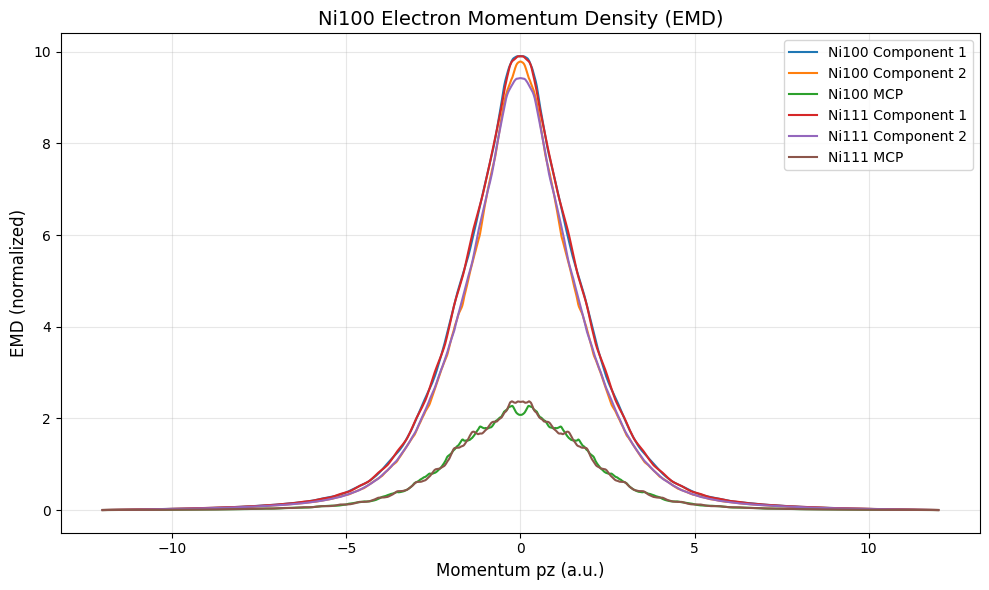

(2401,) (2401,) (2401,)


In [14]:
ni100 = np.loadtxt('Ni_Magnetic_Compton/I_EMD1D.OUT.100', comments = '%')
ni111 = np.loadtxt('Ni_Magnetic_Compton/I_EMD1D.OUT.111', comments = '%')

sf = 1e3

x100 = ni100[:,0]
y100_1 = ni100[:,1] * sf
y100_2 = ni100[:,2] * sf
mcp100 = y100_1 - 0.8 * y100_2

x111= ni111[:,0]
y111_1 = ni111[:,1] * sf
y111_2 = ni111[:,2] * sf
mcp111 = y111_1 - 0.8 * y111_2

plt.figure(figsize=(10, 6))
plt.plot(x100, y100_1, label='Ni100 Component 1')
plt.plot(x100, y100_2, label='Ni100 Component 2')
plt.plot(x100, mcp100, label='Ni100 MCP')
plt.plot(x111, y111_1, label='Ni111 Component 1')
plt.plot(x111, y111_2, label='Ni111 Component 2')
plt.plot(x111, mcp111, label='Ni111 MCP')
plt.xlabel('Momentum pz (a.u.)', fontsize=12)
plt.ylabel('EMD (normalized)', fontsize=12)
plt.title('Ni100 Electron Momentum Density (EMD)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(x100.shape, y100_1.shape, y100_2.shape)

Ni100 spin-up: R² = 0.999938
Ni100 spin-down: R² = 0.999952
Ni111 spin-up: R² = 0.999952
Ni111 spin-down: R² = 0.999976


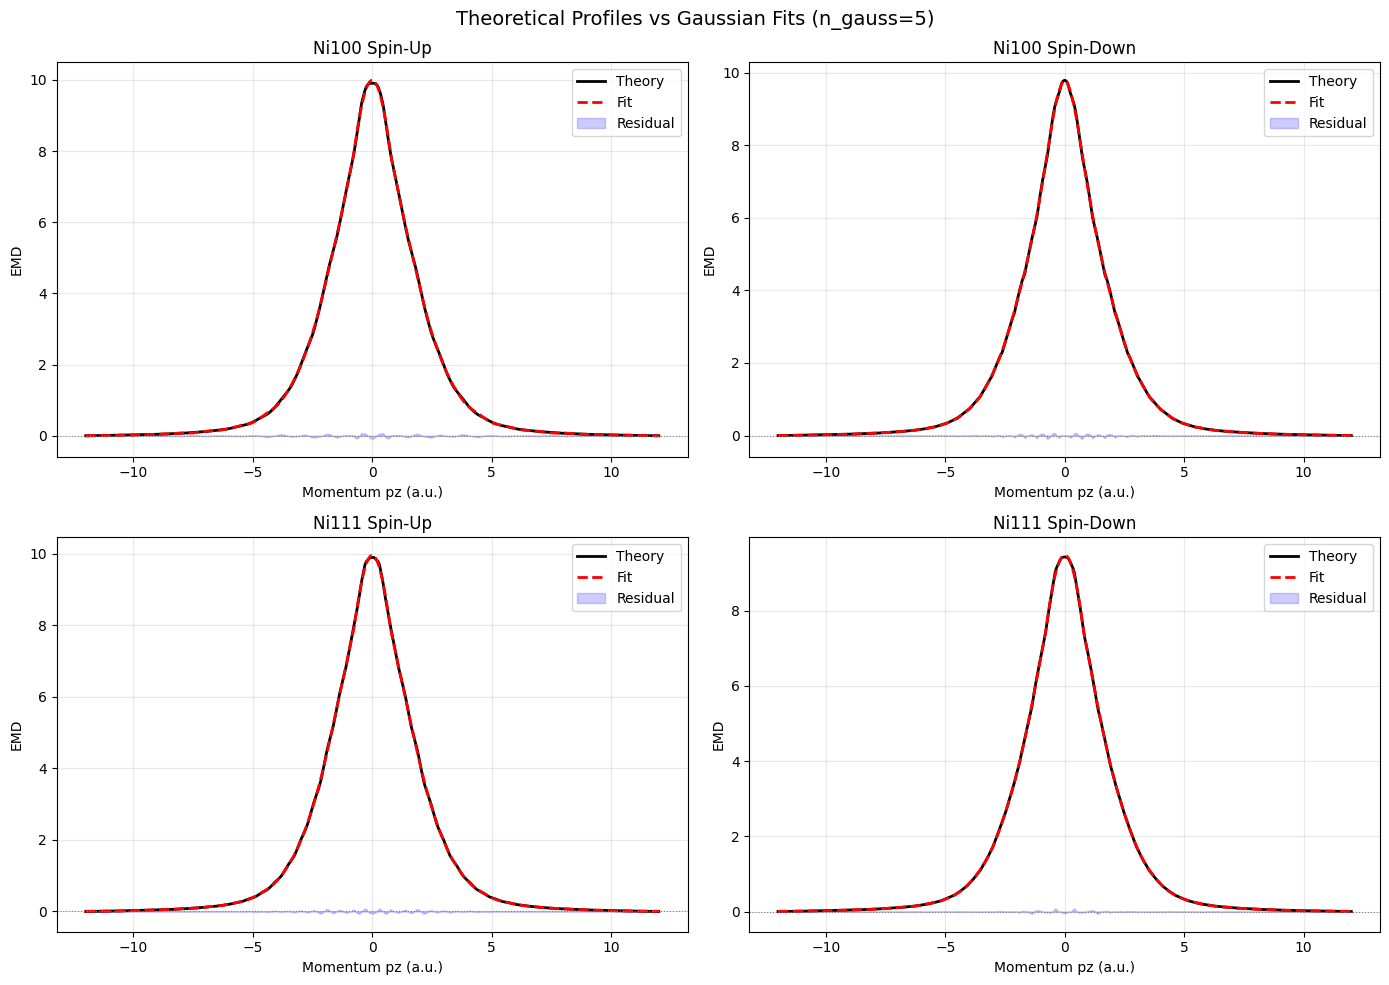

In [145]:
n_gauss   = 5
n_fourier = 7

fermi_window_100 = gaussian(x100, fermi_window_width, fermi_window_amp)
fermi_window_111 = gaussian(x111, fermi_window_width, fermi_window_amp)

popt_100_1, pcov_100_1, popt_fermi_100_1, pcov_fermi_100_1, fit_100_1 = fit_profile(x100, y100_1, fermi_window_100, n_gauss=n_gauss, n_fourier=n_fourier, label='Ni100 spin-up')
popt_100_2, pcov_100_2, popt_fermi_100_2, pcov_fermi_100_2, fit_100_2 = fit_profile(x100, y100_2, fermi_window_100, n_gauss=n_gauss, n_fourier=n_fourier, label='Ni100 spin-down')
popt_111_1, pcov_111_1, popt_fermi_111_1, pcov_fermi_111_1, fit_111_1 = fit_profile(x111, y111_1, fermi_window_111, n_gauss=n_gauss, n_fourier=n_fourier, label='Ni111 spin-up')
popt_111_2, pcov_111_2, popt_fermi_111_2, pcov_fermi_111_2, fit_111_2 = fit_profile(x111, y111_2, fermi_window_111, n_gauss=n_gauss, n_fourier=n_fourier, label='Ni111 spin-down')
# --- Visualise ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Theoretical Profiles vs Gaussian Fits (n_gauss={n_gauss})', fontsize=14)

plot_data = [
    (axes[0,0], x100, y100_1, fit_100_1, 'Ni100 Spin-Up'),
    (axes[0,1], x100, y100_2, fit_100_2, 'Ni100 Spin-Down'),
    (axes[1,0], x111, y111_1, fit_111_1, 'Ni111 Spin-Up'),
    (axes[1,1], x111, y111_2, fit_111_2, 'Ni111 Spin-Down'),
]

for ax, x, y_real, y_fit, title in plot_data:
    ax.plot(x, y_real, 'k-',  lw=2,   label='Theory')
    if y_fit is not None:
        ax.plot(x, y_fit,  'r--', lw=2,   label='Fit')
        ax.fill_between(x, y_real - y_fit, alpha=0.2, color='blue', label='Residual')
        ax.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set_title(title)
    ax.set_xlabel('Momentum pz (a.u.)')
    ax.set_ylabel('EMD')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

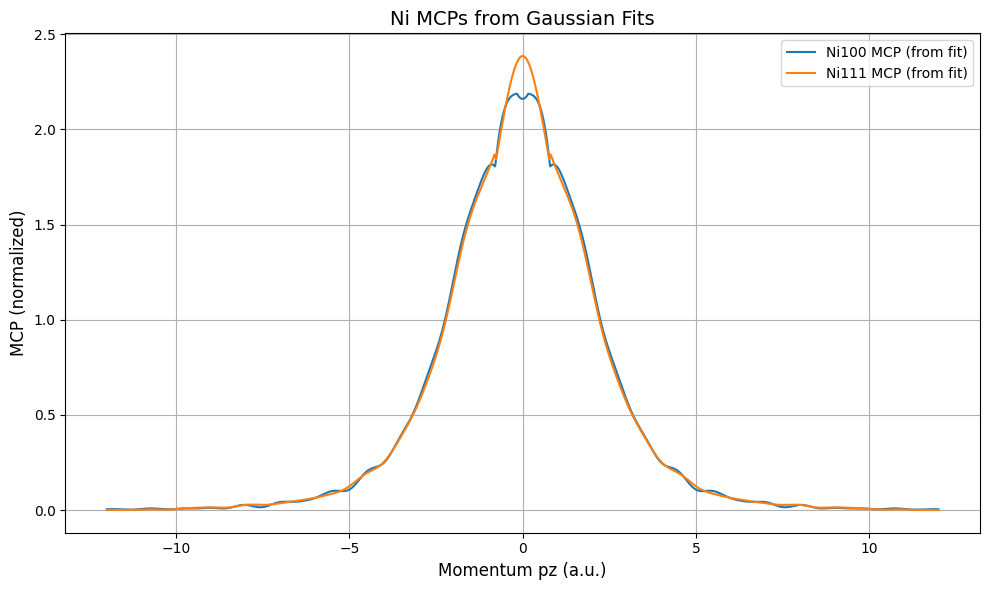

In [146]:
mcp100 = fit_100_1 - 0.8 * fit_100_2
mcp111 = fit_111_1 - 0.8 * fit_111_2

plt.figure(figsize=(10, 6))
plt.plot(x100, mcp100, label='Ni100 MCP (from fit)')
plt.plot(x111, mcp111, label='Ni111 MCP (from fit)')
plt.xlabel('Momentum pz (a.u.)', fontsize=12)
plt.ylabel('MCP (normalized)', fontsize=12)
plt.title('Ni MCPs from Gaussian Fits', fontsize=14)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Ni100 spin-up: R² = 0.999853
Ni100 spin-down: R² = 0.999706
Ni111 spin-up: R² = 0.999880
Ni111 spin-down: R² = 0.999006


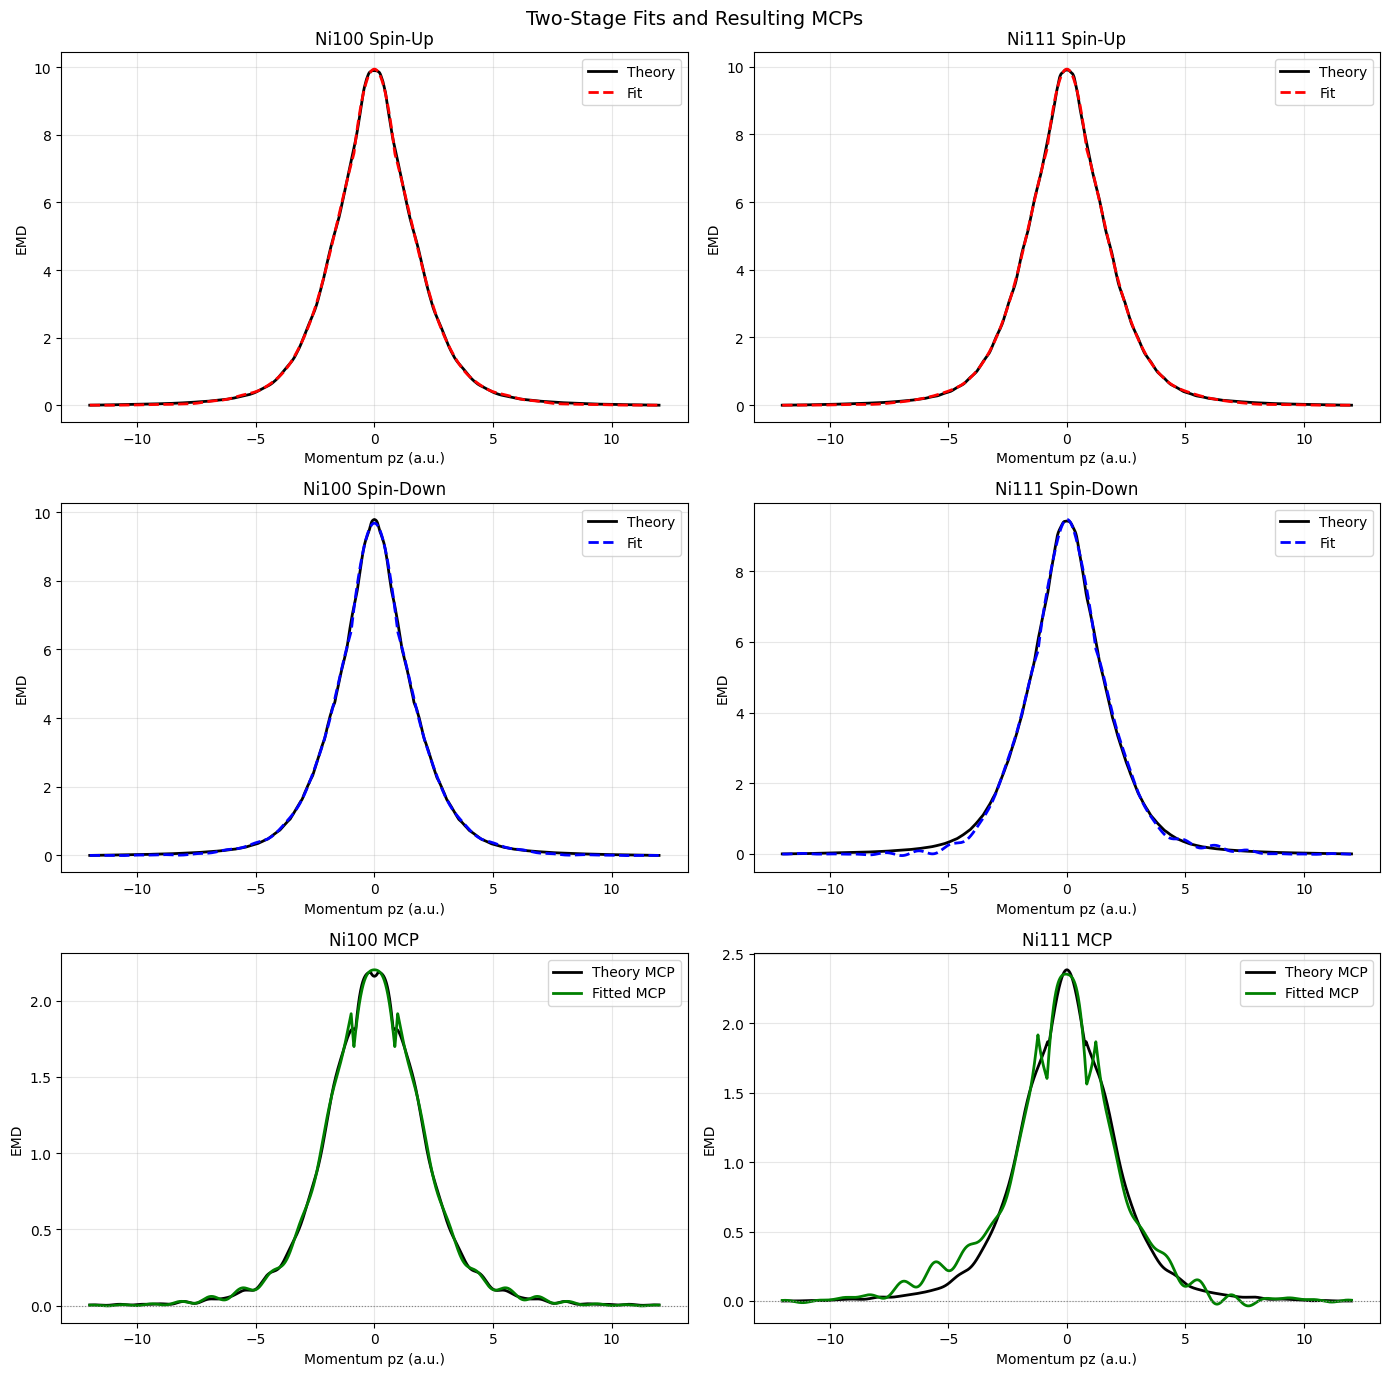

In [147]:
n_gauss   = 4
n_fourier = 5

# Need fermi_window on the same x grid as the data
fermi_window_100 = gaussian(x100, fermi_window_width, fermi_window_amp)
fermi_window_111 = gaussian(x111, fermi_window_width, fermi_window_amp)

results = {}
results['100_up']   = fit_profile_with_fermi(x100, y100_1, fermi_window_100, n_gauss, n_fourier, 'Ni100 spin-up')
results['100_down'] = fit_profile_with_fermi(x100, y100_2, fermi_window_100, n_gauss, n_fourier, 'Ni100 spin-down')
results['111_up']   = fit_profile_with_fermi(x111, y111_1, fermi_window_111, n_gauss, n_fourier, 'Ni111 spin-up')
results['111_down'] = fit_profile_with_fermi(x111, y111_2, fermi_window_111, n_gauss, n_fourier, 'Ni111 spin-down')



fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('Two-Stage Fits and Resulting MCPs', fontsize=14)

for col, direction, x, fw, k_up, k_down, y_up, y_down, mcp_real in [
    (0, '100', x100, fermi_window_100, '100_up', '100_down', y100_1, y100_2, mcp100),
    (1, '111', x111, fermi_window_111, '111_up', '111_down', y111_1, y111_2, mcp111),
]:
    *_, fit_up   = results[k_up]
    *_, fit_down = results[k_down]

    # Spin-up
    axes[0, col].plot(x, y_up,   'k-',  lw=2, label='Theory')
    if fit_up is not None:
        axes[0, col].plot(x, fit_up, 'r--', lw=2, label='Fit')
    axes[0, col].set_title(f'Ni{direction} Spin-Up')
    axes[0, col].legend(); axes[0, col].grid(True, alpha=0.3)

    # Spin-down
    axes[1, col].plot(x, y_down,   'k-',  lw=2, label='Theory')
    if fit_down is not None:
        axes[1, col].plot(x, fit_down, 'b--', lw=2, label='Fit')
    axes[1, col].set_title(f'Ni{direction} Spin-Down')
    axes[1, col].legend(); axes[1, col].grid(True, alpha=0.3)

    # MCP comparison
    axes[2, col].plot(x, mcp_real, 'k-', lw=2, label='Theory MCP')
    if fit_up is not None and fit_down is not None:
        mcp_fit = fit_up - 0.8 * fit_down
        axes[2, col].plot(x, mcp_fit, 'g', lw=2, label='Fitted MCP')
    axes[2, col].axhline(0, color='gray', lw=0.8, ls=':')
    axes[2, col].set_title(f'Ni{direction} MCP')
    axes[2, col].legend(); axes[2, col].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Momentum pz (a.u.)')
    ax.set_ylabel('EMD')

plt.tight_layout()
plt.show()

# Build training datasets:


* tails rising? $\checkmark$
* centre not physical looking $\checkmark$
* blur is wrong still - I think?




Blur might be wrong but its good enough so time to create enough of these to train a CNN and then train and test the CNN. can test on some real profiles. 

In [307]:
import pickle
import numpy as np
from tqdm import tqdm
from datetime import datetime

def build_mcp_dataset(n_samples, pz, n_gauss, gauss_width_range, gauss_amp_range,
                     parab_curv_range, parab_offset_range, fermi_scale_range, 
                     fermi_coeff_range, rng, desc="Generating"):
    """
    Build a dataset of MCP profiles.
    
    Returns:
        Dictionary with arrays for each version of the MCP
    """
    clean_list = []
    blur_list = []
    noisy_list = []
    blur_noisy_list = []
    
    attempts = 0
    max_attempts = n_samples * 20  # Allow some failures
    
    with tqdm(total=n_samples, desc=desc) as pbar:
        while len(clean_list) < n_samples and attempts < max_attempts:
            attempts += 1
            
            result = generate_mcp(pz, n_gauss, gauss_width_range, gauss_amp_range,
                                parab_curv_range, parab_offset_range, 
                                fermi_scale_range, fermi_coeff_range, rng)
            
            if result is not None:
                mcp_clean, mcp_blur, mcp_noisy, mcp_blur_noisy = result
                
                clean_list.append(mcp_clean)
                blur_list.append(mcp_blur)
                noisy_list.append(mcp_noisy)
                blur_noisy_list.append(mcp_blur_noisy)
                
                pbar.update(1)
    
    if len(clean_list) < n_samples:
        print(f"\nWarning: Only generated {len(clean_list)}/{n_samples} valid profiles")
    
    rejection_rate = (attempts - len(clean_list)) / attempts * 100
    print(f"Rejection rate: {rejection_rate:.2f}% ({attempts - len(clean_list)}/{attempts})")
    
    return {
        'clean': np.array(clean_list),
        'blur': np.array(blur_list),
        'noisy': np.array(noisy_list),
        'blur_noisy': np.array(blur_noisy_list),
        'pz': pz,
        'metadata': {
            'n_samples': len(clean_list),
            'n_gaussians': n_gauss,
            'total_counts': t_count,
            'resolution_fwhm': res_fwhm,
            'spin_asymmetry': spin_asymm,
            'generation_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
    }


# Generate Training Dataset (4000 samples)
print("="*70)
print("GENERATING NICKEL MCP TRAINING DATASET")
print("="*70)
print(f"Target: 4000 training profiles\n")

train_data = build_mcp_dataset(
    n_samples=4000,
    pz=pz,
    n_gauss=n_gauss,
    gauss_width_range=gauss_width_range,
    gauss_amp_range=gauss_amp_range,
    parab_curv_range=parab_curv_range,
    parab_offset_range=parab_offset_range,
    fermi_scale_range=fermi_scale_range,
    fermi_coeff_range=fermi_coeff_range,
    rng=rng,
    desc="Training set"
)

print(f"\n✓ Training dataset complete")
print(f"  Shape: {train_data['clean'].shape}")
print(f"  Memory: ~{train_data['clean'].nbytes * 4 / 1e6:.1f} MB")


# Generate Test Dataset (1000 samples)
print("\n" + "="*70)
print("GENERATING NICKEL MCP TEST DATASET")
print("="*70)
print(f"Target: 1000 test profiles\n")

test_data = build_mcp_dataset(
    n_samples=1000,
    pz=pz,
    n_gauss=n_gauss,
    gauss_width_range=gauss_width_range,
    gauss_amp_range=gauss_amp_range,
    parab_curv_range=parab_curv_range,
    parab_offset_range=parab_offset_range,
    fermi_scale_range=fermi_scale_range,
    fermi_coeff_range=fermi_coeff_range,
    rng=rng,
    desc="Test set"
)

print(f"\n✓ Test dataset complete")
print(f"  Shape: {test_data['clean'].shape}")
print(f"  Memory: ~{test_data['clean'].nbytes * 4 / 1e6:.1f} MB")


# Save datasets as pickle files
print("\n" + "="*70)
print("SAVING DATASETS")
print("="*70)

# Save training data
train_filename = 'nickel_mcp_train_4000.pkl'
with open(train_filename, 'wb') as f:
    pickle.dump(train_data, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"✓ Saved: {train_filename}")
#print(f"  Size: {os.path.getsize(train_filename) / 1e6:.2f} MB")

# Save test data
test_filename = 'nickel_mcp_test_1000.pkl'
with open(test_filename, 'wb') as f:
    pickle.dump(test_data, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"✓ Saved: {test_filename}")
#print(f"  Size: {os.path.getsize(test_filename) / 1e6:.2f} MB")


GENERATING NICKEL MCP TRAINING DATASET
Target: 4000 training profiles



Training set:   0%|          | 0/4000 [00:00<?, ?it/s]

Training set: 100%|██████████| 4000/4000 [00:04<00:00, 832.11it/s]


Rejection rate: 0.00% (0/4000)

✓ Training dataset complete
  Shape: (4000, 401)
  Memory: ~51.3 MB

GENERATING NICKEL MCP TEST DATASET
Target: 1000 test profiles



Test set: 100%|██████████| 1000/1000 [00:01<00:00, 828.47it/s]

Rejection rate: 0.00% (0/1000)

✓ Test dataset complete
  Shape: (1000, 401)
  Memory: ~12.8 MB

SAVING DATASETS
✓ Saved: nickel_mcp_train_4000.pkl
✓ Saved: nickel_mcp_test_1000.pkl


In [308]:
filepath = "C:\\Users\\Jpjha\\OneDrive\\Desktop\\Decon by ML\\Code\\nickel_mcp_train_4000.pkl"
training_data = pd.read_pickle(filepath)

training_data['clean']

array([[0.00472852, 0.00499842, 0.00528204, ..., 0.00528204, 0.00499842,
        0.00472852],
       [0.00472665, 0.00499605, 0.0052793 , ..., 0.0052793 , 0.00499605,
        0.00472665],
       [0.00472474, 0.00499435, 0.00527784, ..., 0.00527784, 0.00499435,
        0.00472474],
       ...,
       [0.00472592, 0.00499526, 0.0052785 , ..., 0.0052785 , 0.00499526,
        0.00472592],
       [0.00472457, 0.00499379, 0.00527698, ..., 0.00527698, 0.00499379,
        0.00472457],
       [0.00472428, 0.00499366, 0.0052771 , ..., 0.0052771 , 0.00499366,
        0.00472428]], shape=(4000, 401))

In [309]:
import pickle
import numpy as np

print("="*70)
print("CREATING 4-SAMPLE VISUALIZATION DATASET")
print("="*70)

# Generate 4 samples
viz_samples = {
    'clean': [],
    'blur': [],
    'noisy': [],
    'blur_noisy': []
}

print("\nGenerating 4 validation samples...")

count = 0
attempts = 0
max_attempts = 50

while count < 4 and attempts < max_attempts:
    attempts += 1
    
    result = generate_mcp(pz, n_gauss, gauss_width_range, gauss_amp_range,
                         parab_curv_range, parab_offset_range, 
                         fermi_scale_range, fermi_coeff_range, rng)
    
    if result is not None:
        mcp_clean, mcp_blur, mcp_noisy, mcp_blur_noisy = result
        
        viz_samples['clean'].append(mcp_clean)
        viz_samples['blur'].append(mcp_blur)
        viz_samples['noisy'].append(mcp_noisy)
        viz_samples['blur_noisy'].append(mcp_blur_noisy)
        
        count += 1
        print(f"  ✓ Sample {count} generated")

# Convert to arrays
viz_data = {
    'clean': np.array(viz_samples['clean']),
    'blur': np.array(viz_samples['blur']),
    'noisy': np.array(viz_samples['noisy']),
    'blur_noisy': np.array(viz_samples['blur_noisy']),
    'pz': pz
}

# Save
filename = 'nickel_mcp_viz_4samples.pkl'
with open(filename, 'wb') as f:
    pickle.dump(viz_data, f)

print(f"\n✓ Saved: {filename}")
print(f"  Shapes: {viz_data['clean'].shape}")
print(f"\nTo load:")
print(f"  with open('{filename}', 'rb') as f:")
print(f"      viz_data = pickle.load(f)")
print(f"  X_viz = viz_data['blur_noisy']  # Inputs")
print(f"  y_viz = viz_data['clean']       # Targets")

CREATING 4-SAMPLE VISUALIZATION DATASET

Generating 4 validation samples...
  ✓ Sample 1 generated
  ✓ Sample 2 generated
  ✓ Sample 3 generated
  ✓ Sample 4 generated

✓ Saved: nickel_mcp_viz_4samples.pkl
  Shapes: (4, 401)

To load:
  with open('nickel_mcp_viz_4samples.pkl', 'rb') as f:
      viz_data = pickle.load(f)
  X_viz = viz_data['blur_noisy']  # Inputs
  y_viz = viz_data['clean']       # Targets


# Theoretical MCPs:


* loading some theoretical MCPs to degrade and test on the CNN
* will also aide with the optimisation of training data

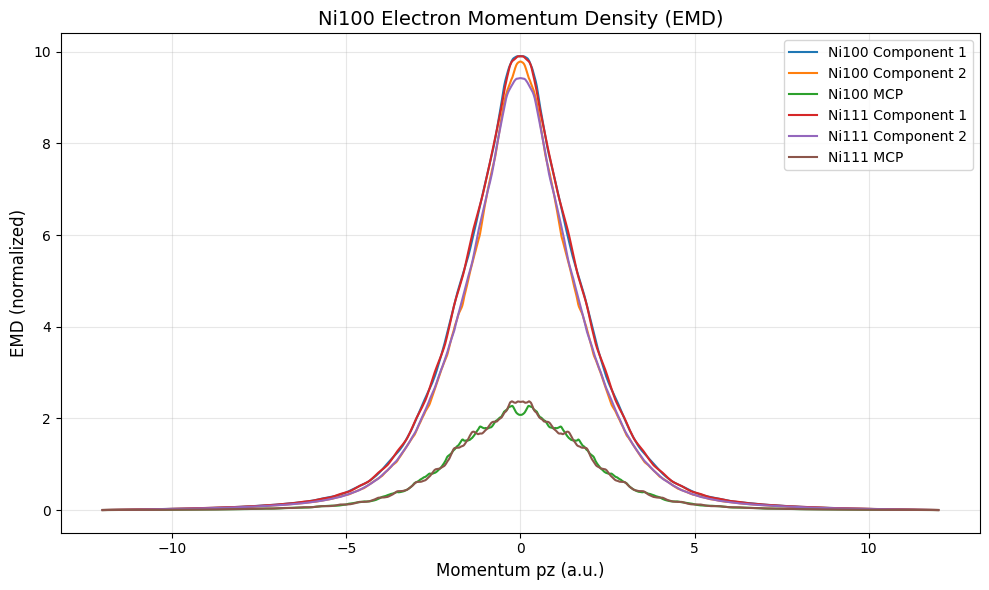

(2401,) (2401,) (2401,)


In [12]:
ni100 = np.loadtxt('Ni_Magnetic_Compton/I_EMD1D.OUT.100', comments = '%')
ni111 = np.loadtxt('Ni_Magnetic_Compton/I_EMD1D.OUT.111', comments = '%')

sf = 1e3

x100 = ni100[:,0]
y100_1 = ni100[:,1] * sf
y100_2 = ni100[:,2] * sf
mcp100 = y100_1 - 0.8 * y100_2

x111= ni111[:,0]
y111_1 = ni111[:,1] * sf
y111_2 = ni111[:,2] * sf
mcp111 = y111_1 - 0.8 * y111_2

plt.figure(figsize=(10, 6))
plt.plot(x100, y100_1, label='Ni100 Component 1')
plt.plot(x100, y100_2, label='Ni100 Component 2')
plt.plot(x100, mcp100, label='Ni100 MCP')
plt.plot(x111, y111_1, label='Ni111 Component 1')
plt.plot(x111, y111_2, label='Ni111 Component 2')
plt.plot(x111, mcp111, label='Ni111 MCP')
plt.xlabel('Momentum pz (a.u.)', fontsize=12)
plt.ylabel('EMD (normalized)', fontsize=12)
plt.title('Ni100 Electron Momentum Density (EMD)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(x100.shape, y100_1.shape, y100_2.shape)

Redefining parameters and functions where values need changing to account for new scale

In [14]:
#grid parameters
Npts = 2401
pz_min = -12.5
pz_max = 12.5

# physical parameters
n_gauss = 5
fourier_order = 5
spin_asymm = 0.8

# experimental parameters
t_count = 5e5
res_fwhm = 0.35
err_scaling = 1

# random parameters
gauss_width_range = (0.3, 2.0)
gauss_amp_range = (0.05, 1.0)
parab_curv_range = (-2.5, -1.5)
parab_offset_range = (1.5, 2.5)

fermi_window_width = 2
fermi_window_amp = 0.5
fermi_scale_range = (0.1, 0.2)
fermi_coeff_range = 0.3

noise_amp = 0.01

n_train = 200000
n_test = 50000

pz = np.linspace(pz_min, pz_max, Npts)
grid_spacing = np.abs(pz[1] - pz[0])
res_sigma = res_fwhm / (2 * np.sqrt(2 * np.log(2))) / grid_spacing


rng = np.random.default_rng()


def blur(y, sigma):
    kernel = gaussian_kernel_1D(size=101, sigma=sigma)
    y = signal.convolve(y, kernel, mode='same')

    return y

def noise(y):
    y_noisy = y + np.sqrt(y) * np.random.normal(0,noise_amp,size=y.shape)
    return y_noisy


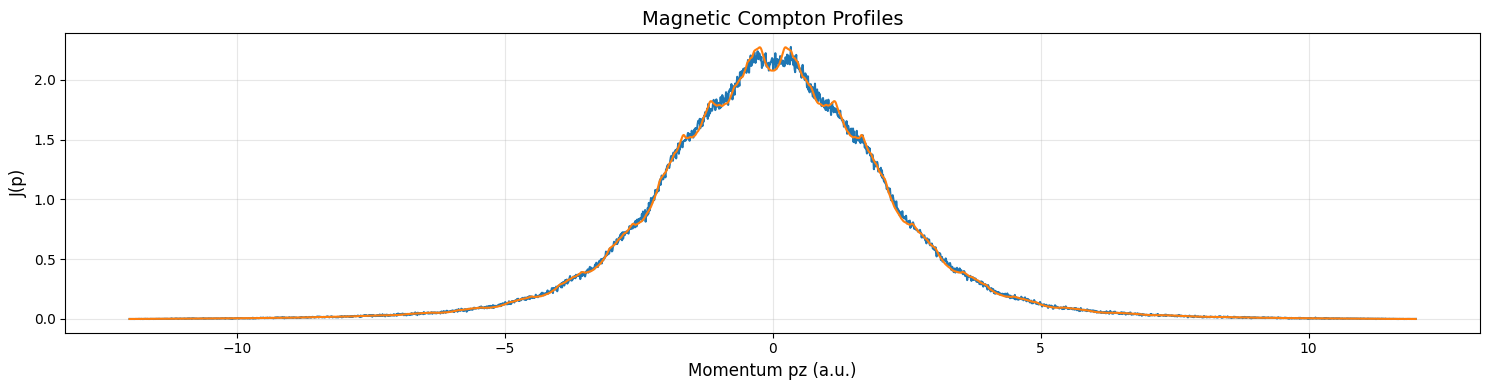

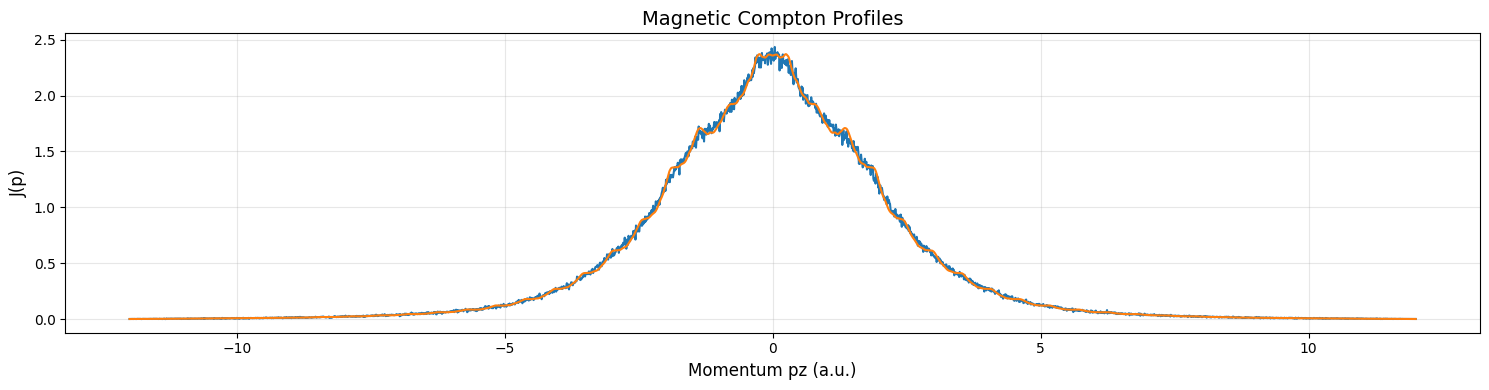

In [15]:
y100_1_blur = blur(y100_1, res_sigma)
y100_1_blur_noise= noise(y100_1_blur)
y100_2_blur = blur(y100_2, res_sigma)
y100_2_blur_noise = noise(y100_2_blur)

mcp100_blur_noise = y100_1_blur_noise - 0.8 * y100_2_blur_noise

y111_1_blur = blur(y111_1, res_sigma)
y111_1_blur_noise= noise(y111_1_blur)
y111_2_blur = blur(y111_2, res_sigma)
y111_2_blur_noise = noise(y111_2_blur)

mcp111_blur_noise = y111_1_blur_noise - 0.8 * y111_2_blur_noise

mcp100_degrade = blur(mcp100, res_sigma)
mcp111_degrade = blur(mcp111, res_sigma)

plt.figure(figsize=(15, 4))
plt.plot(x100, mcp100_blur_noise)
plt.plot(x100, mcp100)
plt.xlabel('Momentum pz (a.u.)', fontsize=12)
plt.ylabel('J(p)', fontsize=12)
plt.title('Magnetic Compton Profiles', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(x100, mcp111_blur_noise)
plt.plot(x111, mcp111)
plt.xlabel('Momentum pz (a.u.)', fontsize=12)
plt.ylabel('J(p)', fontsize=12)
plt.title('Magnetic Compton Profiles', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Save the test profiles for use in other files
import pickle

# Save both profiles together with metadata
profiles_data_100 = {
    'mcp_clean': mcp100,
    'mcp_blur_noisy': mcp100_blur_noise,
    'pz': x100
}

profiles_data_111 = {
    'mcp_clean': mcp111,
    'mcp_blur_noisy': mcp111_blur_noise,
    'pz': x111
}

# Save as pickle file
filename_100 = 'Nickel_100_profiles.pkl'
with open(filename_100, 'wb') as f:
    pickle.dump(profiles_data_100, f)

filename_111 = 'Nickel_111_profiles.pkl'
with open(filename_111, 'wb') as f:
    pickle.dump(profiles_data_111, f)

print(f"✓ Saved profiles to: {filename_100}, {filename_111}")
print(f"  Clean shape: {mcp100.shape}")
print(f"  Blur+Noisy shape: {mcp100_blur_noise.shape}")
print(f"  Clean shape: {mcp111.shape}")
print(f"  Blur+Noisy shape: {mcp111_blur_noise.shape}")


✓ Saved profiles to: Nickel_100_profiles.pkl, Nickel_111_profiles.pkl
  Clean shape: (2401,)
  Blur+Noisy shape: (2401,)
  Clean shape: (2401,)
  Blur+Noisy shape: (2401,)


## Filtering the synthetic profiles

Building a system to filter out potentially viable syntetic MCPs from unphysical ones

In [397]:
'''

The Following code was produced using Claude AI 

prompt: 
take redced chi squared of syntetic mcp against each direction
if smallest value is greater than a target value then reject the profile
accpeted profiles are affed to the dataframe to produce pickle data
repeat until 4000 profiles are accepted for training and 1000 for testing

It has since been edited

'''

from scipy.interpolate import interp1d
import pickle
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

noise_amp = 30

def noise(y):
    y_noisy = y + np.sqrt(np.abs(y)) * np.random.normal(0,0.1,size=y.shape)
    return y_noisy



# ── Configuration ─────────────────────────────────────────────────────────────
N_TRAIN        = 5000
N_TEST         = 1000
CHI2_THRESHOLD = 3.5    # reject if best reduced chi-sq across both orientations exceeds this
                         # tune this — tighter (~2) = more physical, looser (~10) = more variety

# Use the DFT theoretical profiles already loaded in this notebook as reference.
# Since there are no experimental error bars, we estimate the noise floor as a
# fixed fraction of the peak amplitude of each reference profile.
NOISE_FRACTION = 0.05   # 5% of peak amplitude used as proxy error bar

reference_profiles = {
    '100': {'pz': x100, 'mcp': mcp100},
    '111': {'pz': x111, 'mcp': mcp111},
}

# ── Helper: reduced chi-squared ───────────────────────────────────────────────
def reduced_chi_squared(pz_synth, mcp_synth, pz_ref, mcp_ref):
    """
    Interpolates the synthetic profile onto the reference pz grid and computes
    a reduced chi-squared.  Since we have no experimental error bars, a uniform
    error equal to NOISE_FRACTION * peak(mcp_ref) is assumed across all points.

    Parameters
    ----------
    pz_synth  : 1-D array  momentum axis of synthetic profile (2401 pts, ±12.5)
    mcp_synth : 1-D array  synthetic MCP values
    pz_ref    : 1-D array  reference (DFT) momentum axis
    mcp_ref   : 1-D array  reference MCP values

    Returns
    -------
    float  reduced chi-squared
    """
    # Restrict comparison to the overlapping momentum range
    pz_lo = max(pz_synth.min(), pz_ref.min())
    pz_hi = min(pz_synth.max(), pz_ref.max())

    mask       = (pz_ref >= pz_lo) & (pz_ref <= pz_hi)
    pz_cut     = pz_ref[mask]
    mcp_ref_cut = mcp_ref[mask]

    # Interpolate synthetic onto reference grid
    interp_fn     = interp1d(pz_synth, mcp_synth, kind='cubic')
    mcp_synth_cut = interp_fn(pz_cut)

    # Normalise synthetic so its integral matches the reference
    norm_ref   = np.trapz(mcp_ref_cut,   pz_cut)
    norm_synth = np.trapz(mcp_synth_cut, pz_cut)
    if norm_synth == 0:
        return np.inf
    mcp_synth_cut *= norm_ref / norm_synth

    # Proxy error: fixed fraction of reference peak amplitude
    error = NOISE_FRACTION * np.max(np.abs(mcp_ref_cut))
    if error == 0:
        return np.inf

    n_points = len(pz_cut)
    chi2     = np.sum(((mcp_ref_cut - mcp_synth_cut) / error) ** 2)
    return chi2 / n_points


# ── Generation loop ───────────────────────────────────────────────────────────
records_train = []
records_test  = []
n_accepted    = 0
n_rejected    = 0
target_total  = N_TRAIN + N_TEST

pbar = tqdm(total=target_total, desc='Generating filtered profiles')

while n_accepted < target_total:

    # Generate a candidate synthetic MCP
    result = generate_mcp(
        pz, n_gauss, gauss_width_range, gauss_amp_range,
        parab_curv_range, parab_offset_range,
        fermi_scale_range, fermi_coeff_range, rng
    )

    # generate_mcp returns None (via recursion guard) if sign_consistency fails;
    # guard against that here just in case
    if result is None:
        n_rejected += 1
        continue

    mcp_clean, mcp_blur, mcp_noisy, mcp_blur_noisy = result

    # Compute reduced chi-squared against each reference orientation
    chi2_per_orientation = {
        ori: reduced_chi_squared(
            pz_synth  = pz,
            mcp_synth = mcp_clean,
            pz_ref    = reference_profiles[ori]['pz'],
            mcp_ref   = reference_profiles[ori]['mcp']
        )
        for ori in reference_profiles
    }

    best_chi2        = min(chi2_per_orientation.values())
    best_orientation = min(chi2_per_orientation, key=chi2_per_orientation.get)

    # Reject if no orientation gives a close enough match
    if best_chi2 > CHI2_THRESHOLD:
        n_rejected += 1
        continue

    # Build record
    record = {
        'mcp_clean'       : mcp_clean,
        'mcp_blur'        : mcp_blur,
        'mcp_noisy'       : mcp_noisy,
        'mcp_blur_noisy'  : mcp_blur_noisy,
        'pz'              : pz,
        'best_chi2'       : best_chi2,
        'best_orientation': best_orientation,
        **{f'chi2_{ori}': chi2_per_orientation[ori] for ori in reference_profiles}
    }

    # Fill train first, then test
    if len(records_train) < N_TRAIN:
        records_train.append(record)
    else:
        records_test.append(record)

    n_accepted += 1
    pbar.update(1)

pbar.close()

total_attempts = n_accepted + n_rejected
print(f'\nFinished: {n_accepted} accepted, {n_rejected} rejected '
      f'({100 * n_rejected / total_attempts:.1f}% rejection rate)')

# ── Assemble and save ─────────────────────────────────────────────────────────
df_train = pd.DataFrame(records_train)
df_test  = pd.DataFrame(records_test)

# Also expose as numpy arrays in the same format as build_mcp_dataset above,
# so the rest of the notebook (CNN training cells) can use either output format.
train_data = {
    'clean'      : np.stack(df_train['mcp_clean'].values),
    'blur'       : np.stack(df_train['mcp_blur'].values),
    'noisy'      : np.stack(df_train['mcp_noisy'].values),
    'blur_noisy' : np.stack(df_train['mcp_blur_noisy'].values),
    'pz'         : pz,
    'chi2'       : df_train['best_chi2'].values,
    'metadata'   : {
        'n_samples'       : len(df_train),
        'chi2_threshold'  : CHI2_THRESHOLD,
        'noise_fraction'  : NOISE_FRACTION,
        'n_gaussians'     : n_gauss,
        'total_counts'    : t_count,
        'resolution_fwhm' : res_fwhm,
        'spin_asymmetry'  : spin_asymm,
        'generation_date' : datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }
}

test_data = {
    'clean'      : np.stack(df_test['mcp_clean'].values),
    'blur'       : np.stack(df_test['mcp_blur'].values),
    'noisy'      : np.stack(df_test['mcp_noisy'].values),
    'blur_noisy' : np.stack(df_test['mcp_blur_noisy'].values),
    'pz'         : pz,
    'chi2'       : df_test['best_chi2'].values,
    'metadata'   : {**train_data['metadata'], 'n_samples': len(df_test)}
}

train_filename = 'nickel_mcp_train_filtered_4000.pkl'
test_filename  = 'nickel_mcp_test_filtered_1000.pkl'

with open(train_filename, 'wb') as f:
    pickle.dump(train_data, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(test_filename, 'wb') as f:
    pickle.dump(test_data, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f'\n✓ Saved: {train_filename}  —  shape: {train_data["clean"].shape}')
print(f'✓ Saved: {test_filename}   —  shape: {test_data["clean"].shape}')
print(f'\nchi² summary (training set):')
print(f'  mean : {df_train["best_chi2"].mean():.3f}')
print(f'  std  : {df_train["best_chi2"].std():.3f}')
print(f'  max  : {df_train["best_chi2"].max():.3f}')
print(f'  best_orientation breakdown:\n{df_train["best_orientation"].value_counts().to_string()}')

Generating filtered profiles:   0%|          | 0/6000 [00:00<?, ?it/s]

C:\Users\Jpjha\AppData\Local\Temp\ipykernel_22852\445193603.py:77: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_ref   = np.trapz(mcp_ref_cut,   pz_cut)
C:\Users\Jpjha\AppData\Local\Temp\ipykernel_22852\445193603.py:78: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_synth = np.trapz(mcp_synth_cut, pz_cut)
Generating filtered profiles: 100%|██████████| 6000/6000 [03:17<00:00, 30.45it/s]



Finished: 6000 accepted, 84069 rejected (93.3% rejection rate)

✓ Saved: nickel_mcp_train_filtered_4000.pkl  —  shape: (5000, 401)
✓ Saved: nickel_mcp_test_filtered_1000.pkl   —  shape: (1000, 401)

chi² summary (training set):
  mean : 3.145
  std  : 0.279
  max  : 3.500
  best_orientation breakdown:
best_orientation
111    3944
100    1056


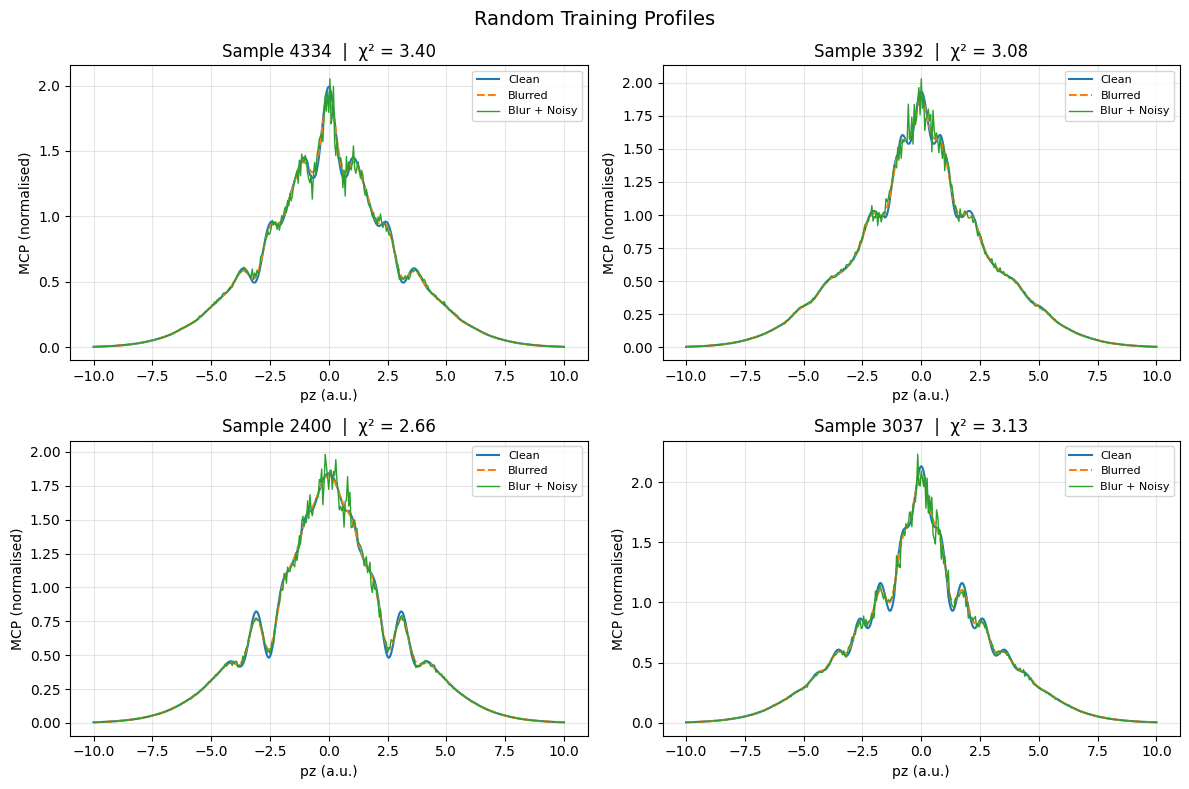

In [398]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

with open('nickel_mcp_train_filtered_4000.pkl', 'rb') as f:
    train_data = pickle.load(f)

pz = train_data['pz']
indices = np.random.choice(len(train_data['clean']), 4, replace=False)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, idx in enumerate(indices):
    axs[i].plot(pz, train_data['clean'][idx],      label='Clean',         lw=1.5)
    axs[i].plot(pz, train_data['blur'][idx],        label='Blurred',       lw=1.5, linestyle='--')
    axs[i].plot(pz, train_data['blur_noisy'][idx],  label='Blur + Noisy',  lw=1,   alpha=1)
    axs[i].set_title(f'Sample {idx}  |  χ² = {train_data["chi2"][idx]:.2f}')
    axs[i].set_xlabel('pz (a.u.)')
    axs[i].set_ylabel('MCP (normalised)')
    axs[i].legend(fontsize=8)
    axs[i].grid(True, alpha=0.3)

plt.suptitle('Random Training Profiles', fontsize=14)
plt.tight_layout()
plt.show()